#Fake News Classifier Using LSTM
Dataset: https://www.kaggle.com/c/fake-news/data#

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix,classification_report
import string

C:\Users\ASUS\anaconda3\lib\site-packages\pandas\core\computation\expressions.py:20: UserWarning: Pandas requires version '2.7.3' or newer of 'numexpr' (version '2.7.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [2]:
data_fake=pd.read_csv('Fake.csv')
data_true=pd.read_csv('True.csv')


In [3]:
data_fake.head()

,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017"
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017"


In [4]:
data_true.tail()


,title,text,subject,date
21412,'Fully committed' NATO backs new U.S. approach...,BRUSSELS (Reuters) - NATO allies on Tuesday we...,worldnews,"August 22, 2017"
21413,LexisNexis withdrew two products from Chinese ...,"LONDON (Reuters) - LexisNexis, a provider of l...",worldnews,"August 22, 2017"
21414,Minsk cultural hub becomes haven from authorities,MINSK (Reuters) - In the shadow of disused Sov...,worldnews,"August 22, 2017"
21415,Vatican upbeat on possibility of Pope Francis ...,MOSCOW (Reuters) - Vatican Secretary of State ...,worldnews,"August 22, 2017"
21416,Indonesia to buy $1.14 billion worth of Russia...,JAKARTA (Reuters) - Indonesia will buy 11 Sukh...,worldnews,"August 22, 2017"


In [5]:
data_fake['class']=0
data_true['class']=1

In [6]:
data_fake.shape,data_true.shape

((23481, 5), (21417, 5))

In [7]:
data_fake_manual_testing=data_fake.tail(10)
for i in range(23480,23470,-1):
    data_fake.drop([i], axis=0,inplace=True)
    
data_true_manual_testing=data_true.tail(10)
for i in range(21416,21406,-1):
    data_true.drop([i], axis=0,inplace=True)    
    
    

In [8]:
data_fake.shape,data_true.shape

((23471, 5), (21407, 5))

In [9]:
data_fake_manual_testing['class']=0
data_true_manual_testing['class']=1

<ipython-input-9-350d73592787>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_fake_manual_testing['class']=0
<ipython-input-9-350d73592787>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_true_manual_testing['class']=1


In [10]:
data_fake_manual_testing.head(10)

,title,text,subject,date,class
23471,Seven Iranians freed in the prisoner swap have...,"21st Century Wire says This week, the historic...",Middle-east,"January 20, 2016",0
23472,#Hashtag Hell & The Fake Left,By Dady Chery and Gilbert MercierAll writers ...,Middle-east,"January 19, 2016",0
23473,Astroturfing: Journalist Reveals Brainwashing ...,Vic Bishop Waking TimesOur reality is carefull...,Middle-east,"January 19, 2016",0
23474,The New American Century: An Era of Fraud,Paul Craig RobertsIn the last years of the 20t...,Middle-east,"January 19, 2016",0
23475,Hillary Clinton: ‘Israel First’ (and no peace ...,Robert Fantina CounterpunchAlthough the United...,Middle-east,"January 18, 2016",0
23476,McPain: John McCain Furious That Iran Treated ...,21st Century Wire says As 21WIRE reported earl...,Middle-east,"January 16, 2016",0
23477,JUSTICE? Yahoo Settles E-mail Privacy Class-ac...,21st Century Wire says It s a familiar theme. ...,Middle-east,"January 16, 2016",0
23478,Sunnistan: US and Allied ‘Safe Zone’ Plan to T...,Patrick Henningsen 21st Century WireRemember ...,Middle-east,"January 15, 2016",0
23479,How to Blow $700 Million: Al Jazeera America F...,21st Century Wire says Al Jazeera America will...,Middle-east,"January 14, 2016",0
23480,10 U.S. Navy Sailors Held by Iranian Military ...,21st Century Wire says As 21WIRE predicted in ...,Middle-east,"January 12, 2016",0


In [11]:
data_true_manual_testing.head(10)

,title,text,subject,date,class
21407,"Mata Pires, owner of embattled Brazil builder ...","SAO PAULO (Reuters) - Cesar Mata Pires, the ow...",worldnews,"August 22, 2017",1
21408,"U.S., North Korea clash at U.N. forum over nuc...",GENEVA (Reuters) - North Korea and the United ...,worldnews,"August 22, 2017",1
21409,"U.S., North Korea clash at U.N. arms forum on ...",GENEVA (Reuters) - North Korea and the United ...,worldnews,"August 22, 2017",1
21410,Headless torso could belong to submarine journ...,COPENHAGEN (Reuters) - Danish police said on T...,worldnews,"August 22, 2017",1
21411,North Korea shipments to Syria chemical arms a...,UNITED NATIONS (Reuters) - Two North Korean sh...,worldnews,"August 21, 2017",1
21412,'Fully committed' NATO backs new U.S. approach...,BRUSSELS (Reuters) - NATO allies on Tuesday we...,worldnews,"August 22, 2017",1
21413,LexisNexis withdrew two products from Chinese ...,"LONDON (Reuters) - LexisNexis, a provider of l...",worldnews,"August 22, 2017",1
21414,Minsk cultural hub becomes haven from authorities,MINSK (Reuters) - In the shadow of disused Sov...,worldnews,"August 22, 2017",1
21415,Vatican upbeat on possibility of Pope Francis ...,MOSCOW (Reuters) - Vatican Secretary of State ...,worldnews,"August 22, 2017",1
21416,Indonesia to buy $1.14 billion worth of Russia...,JAKARTA (Reuters) - Indonesia will buy 11 Sukh...,worldnews,"August 22, 2017",1


In [12]:
data_merge=pd.concat([data_fake,data_true],axis=0)
data_merge.head(10)

,title,text,subject,date,class
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",0
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",0
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",0
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",0
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",0
5,Racist Alabama Cops Brutalize Black Boy While...,The number of cases of cops brutalizing and ki...,News,"December 25, 2017",0
6,"Fresh Off The Golf Course, Trump Lashes Out A...",Donald Trump spent a good portion of his day a...,News,"December 23, 2017",0
7,Trump Said Some INSANELY Racist Stuff Inside ...,In the wake of yet another court decision that...,News,"December 23, 2017",0
8,Former CIA Director Slams Trump Over UN Bully...,Many people have raised the alarm regarding th...,News,"December 22, 2017",0
9,WATCH: Brand-New Pro-Trump Ad Features So Muc...,Just when you might have thought we d get a br...,News,"December 21, 2017",0


In [13]:
data_merge.columns

Index(['title', 'text', 'subject', 'date', 'class'], dtype='object')

In [14]:
data=data_merge.drop(['title','subject','date'],axis=1)

In [15]:
data.isnull().sum()

text     0
class    0
dtype: int64

In [16]:
data=data.sample(frac=1)
data.head()

,text,class
23401,"21st Century Wire says At some point, the poli...",0
15717,GET OVER YOURSELF! MOOCH PLAYS THE RACE CARD A...,0
250,You know how we all joke about Donald Trump s ...,0
19867,,0
1529,Donald Trump thanked outgoing FBI Director Jam...,0


In [17]:
data.reset_index(inplace=True)
data.drop(['index'],axis=1,inplace=True)

In [18]:
data.columns


Index(['text', 'class'], dtype='object')

In [19]:
data.head()

,text,class
0,"21st Century Wire says At some point, the poli...",0
1,GET OVER YOURSELF! MOOCH PLAYS THE RACE CARD A...,0
2,You know how we all joke about Donald Trump s ...,0
3,,0
4,Donald Trump thanked outgoing FBI Director Jam...,0


In [20]:
def text_processor(text):
    # Convert text to lowercase
    text = text.lower()

    # Remove text within square brackets (e.g., [abc/])
    text = re.sub(r'\[.*?\]', '', text)

    # Remove non-word characters (except spaces)
    text = re.sub(r'[^\w\s]', '', text)

    # Remove URLs
    text = re.sub(r'https?://\S+|www\.\S+', '', text)

    # Remove specific special characters: <, >, *, ?, +
    text = re.sub(r'[<>*?+]', '', text)

    # Remove punctuation
    text = re.sub(f"[{re.escape(string.punctuation)}]", '', text)

    # Remove newlines
    text = re.sub(r'\n', '', text)

    # Remove words containing numbers (e.g., abc123)
    text = re.sub(r'\w*\d\w*', '', text)

    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    return text


In [21]:
data['text']=data['text'].apply(text_processor)

In [22]:
x=data['text']
y=data['class']

In [23]:
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

# Assume x and y are defined (x: text data, y: labels)
# Step 1: Split the data into training and testing sets
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.25, random_state=42)

# Step 2: Handle NaN values in y_train and y_test
if np.isnan(y_train).sum() > 0:
    y_train = np.where(np.isnan(y_train), -1, y_train)  # Replace NaN with -1

if np.isnan(y_test).sum() > 0:
    y_test = np.where(np.isnan(y_test), -1, y_test)  # Replace NaN with -1

# Step 3: Check distribution after handling NaN values
print("Unique classes in y_train after handling NaN:", np.unique(y_train))
print("Class distribution in y_train after handling NaN:\n", pd.Series(y_train).value_counts(dropna=False))

# Step 4: Apply TF-IDF vectorization
vectorization = TfidfVectorizer(max_features=5000)
xv_train = vectorization.fit_transform(x_train)
xv_test = vectorization.transform(x_test)

# Step 5: Train the Decision Tree Classifier (only if at least two classes exist)
if len(np.unique(y_train)) >= 2:
    DT = DecisionTreeClassifier(max_depth=10, random_state=42)  # Adjust max_depth as needed
    DT.fit(xv_train, y_train)

    # Step 6: Ensure y_test does not contain NaN before evaluation
    print("Number of NaN values in y_test:", np.isnan(y_test).sum())

    # Step 7: Evaluate the model
    y_pred = DT.predict(xv_test)
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Classification Report:\n", classification_report(y_test, y_pred))
else:
    print("Error: y_train contains only one class after handling NaN values. Classification is not possible.")


Unique classes in y_train after handling NaN: [0 1]
Class distribution in y_train after handling NaN:
 class
0    17646
1    16012
Name: count, dtype: int64
Number of NaN values in y_test: 0
Accuracy: 0.9954545454545455
Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.99      1.00      5825
           1       0.99      1.00      1.00      5395

    accuracy                           1.00     11220
   macro avg       1.00      1.00      1.00     11220
weighted avg       1.00      1.00      1.00     11220



In [24]:
from sklearn.ensemble import GradientBoostingClassifier

# Step 1: Train the Gradient Boosting Classifier (only if at least two classes exist)
if len(np.unique(y_train)) >= 2:
    GBC = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
    GBC.fit(xv_train, y_train)

    # Step 2: Ensure y_test does not contain NaN before evaluation
    print("Number of NaN values in y_test:", np.isnan(y_test).sum())

    # Step 3: Evaluate the model
    y_pred_gbc = GBC.predict(xv_test)
    print("Gradient Boosting Classifier - Accuracy:", accuracy_score(y_test, y_pred_gbc))
    print("Gradient Boosting Classifier - Classification Report:\n", classification_report(y_test, y_pred_gbc))
else:
    print("Error: y_train contains only one class after handling NaN values. Classification is not possible.")


Number of NaN values in y_test: 0
Gradient Boosting Classifier - Accuracy: 0.9950089126559715
Gradient Boosting Classifier - Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.99      1.00      5825
           1       0.99      1.00      0.99      5395

    accuracy                           1.00     11220
   macro avg       0.99      1.00      1.00     11220
weighted avg       1.00      1.00      1.00     11220



Gradient Boosting Classifier - Accuracy: 0.9950089126559715
Gradient Boosting Classifier - Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.99      1.00      5825
           1       0.99      1.00      0.99      5395

    accuracy                           1.00     11220
   macro avg       0.99      1.00      1.00     11220
weighted avg       1.00      1.00      1.00     11220



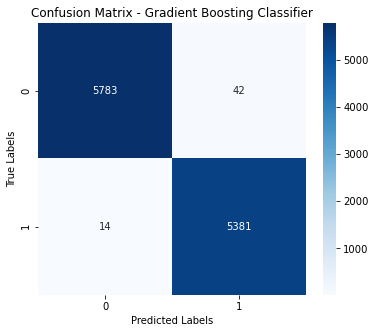

In [25]:
# Step 1: Train Gradient Boosting Classifier (as before)
if len(np.unique(y_train)) >= 2:
    GBC = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
    GBC.fit(xv_train, y_train)

    # Step 2: Predict on test set
    y_pred_gbc = GBC.predict(xv_test)

    # Step 3: Evaluate the model
    accuracy = accuracy_score(y_test, y_pred_gbc)
    print("Gradient Boosting Classifier - Accuracy:", accuracy)
    print("Gradient Boosting Classifier - Classification Report:\n", classification_report(y_test, y_pred_gbc))

    # Step 4: Compute Confusion Matrix
    cm = confusion_matrix(y_test, y_pred_gbc)

    # Step 5: Plot Confusion Matrix using Seaborn
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))
    plt.xlabel("Predicted Labels")
    plt.ylabel("True Labels")
    plt.title("Confusion Matrix - Gradient Boosting Classifier")
    plt.show()
else:
    print("Error: y_train contains only one class after handling NaN values. Classification is not possible.")